![Bank Customer Insights](bankprojectimage.png)
# 🏦 Bank Customer Churn Analysis
**Dataset:** Bank Customer Churn (Messy Excel — multi-sheet)  
**Tools:** Python · Pandas · Scikit-learn · Seaborn · Matplotlib  

---

## Project Overview

Customer churn — when a customer closes their account and leaves the bank — is one of the costliest problems in retail banking. Acquiring a new customer can cost **5–7× more** than retaining an existing one.

This project covers:
1. **Data Cleaning & Merging** of a messy, multi-sheet Excel workbook
2. **Exploratory Data Analysis** to surface key churn drivers
3. **Classification Modelling** — Logistic Regression (baseline) and a tuned Random Forest
4. **Customer Segmentation** using K-Means clustering, with actionable product recommendations

---

## Table of Contents
| # | Section |
|---|---------|
| 1 | Data Loading & Merging |
| 2 | Data Cleaning |
| 3 | Exploratory Data Analysis |
| 4 | Feature Engineering & Data Prep |
| 5 | Baseline Model: Logistic Regression |
| 6 | Improved Model: Random Forest (Tuned) |
| 7 | Customer Segmentation: K-Means |
| 8 | Recommendations |


---
## 1 · Data Loading & Merging

The raw data is a messy Excel workbook with **two sheets**:
- **Sheet 0** — Customer demographics (name, geography, gender, age)
- **Sheet 1** — Account information (balance, products, tenure, churn flag)

We load both and join on `CustomerId` using a left join, preserving all customers even if account data is missing.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Global plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 13, "axes.labelsize": 11})


In [8]:

customer_df = pd.read_excel("C:/Users/debad/Downloads/Bank+Customer+Churn/Bank_Churn_Messy.xlsx", sheet_name = 0)
account_df = pd.read_excel("C:/Users/debad/Downloads/Bank+Customer+Churn/Bank_Churn_Messy.xlsx", sheet_name = 1)

print(f"Customer sheet: {customer_df.shape[0]:,} rows x {customer_df.shape[1]} cols")
print(f"Account sheet:  {account_df.shape[0]:,} rows x {account_df.shape[1]} cols")


Customer sheet: 10,001 rows x 8 cols
Account sheet:  10,002 rows x 7 cols


In [9]:
# Left join keeps all customers even if account data is missing
joined_df = customer_df.merge(account_df, how="left", on="CustomerId")
print(f"Joined shape: {joined_df.shape}")
joined_df.head()


Joined shape: (10004, 14)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure_x,EstimatedSalary,Balance,NumOfProducts,HasCrCard,Tenure_y,IsActiveMember,Exited
0,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
1,15634602,Hargrave,619,FRA,Female,42.0,2,€101348.88,€0.0,1,Yes,2,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,€112542.58,€83807.86,1,Yes,1,Yes,0
3,15619304,Onio,502,French,Female,42.0,8,€113931.57,€159660.8,3,No,8,No,1
4,15701354,Boni,699,FRA,Female,39.0,1,€93826.63,€0.0,2,No,1,No,0


In [10]:
joined_df.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 10004 entries, 0 to 10003
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10004 non-null  int64  
 1   Surname          10001 non-null  object 
 2   CreditScore      10004 non-null  int64  
 3   Geography        10004 non-null  object 
 4   Gender           10004 non-null  object 
 5   Age              10001 non-null  float64
 6   Tenure_x         10004 non-null  int64  
 7   EstimatedSalary  10004 non-null  object 
 8   Balance          10004 non-null  object 
 9   NumOfProducts    10004 non-null  int64  
 10  HasCrCard        10004 non-null  object 
 11  Tenure_y         10004 non-null  int64  
 12  IsActiveMember   10004 non-null  object 
 13  Exited           10004 non-null  int64  
dtypes: float64(1), int64(6), object(7)
memory usage: 1.1+ MB


In [11]:
# Tenure appears in both sheets — drop the redundant right-side copy
joined_df = (
    joined_df
    .drop("Tenure_y", axis=1)
    .rename({"Tenure_x": "Tenure"}, axis=1)
)

n_dupes = joined_df.duplicated(keep=False).sum()
print(f"Duplicate rows found: {n_dupes:,}")


Duplicate rows found: 6


---
## 2 · Data Cleaning

| Issue | Column(s) | Fix |
|-------|-----------|-----|
| Duplicate rows | All | `drop_duplicates()` |
| Currency symbols in numeric fields | `EstimatedSalary`, `Balance` | Strip `€`, cast to `float` |
| Missing values | `Surname`, `Age` | Fill with `"MISSING"` / median |
| Sentinel value for missing salary | `EstimatedSalary` | Replace `-999999` with median |
| Inconsistent country labels | `Geography` | Normalise `"FRA"`, `"French"` → `"France"` |

All steps are bundled into one reproducible pipeline.

> ⚠️ **Caveat on median imputation for `Age`:** This assumes data is **Missing at Random (MAR)** — i.e. missingness is unrelated to age itself. If younger or older customers are systematically missing, median imputation introduces bias. Always validate this assumption.


In [13]:
DATA_PATH = "C:/Users/debad/Downloads/Bank+Customer+Churn/Bank_Churn_Messy.xlsx"

churn_df = (
    pd.read_excel(DATA_PATH, sheet_name=0)
    .merge(pd.read_excel(DATA_PATH, sheet_name=1), how="left", on="CustomerId")
    .drop_duplicates()
    .drop("Tenure_y", axis=1)
    .rename({"Tenure_x": "Tenure"}, axis=1)
    .assign(
        EstimatedSalary = lambda x: x["EstimatedSalary"].str.replace("€", "", regex=False).astype("float"),
        Balance         = lambda x: x["Balance"].str.replace("€", "", regex=False).astype("float"),
        Geography       = lambda x: np.where(
            x["Geography"].isin(["FRA", "France", "French"]), "France", x["Geography"]
        )
    )
    .assign(
        EstimatedSalary = lambda x: x["EstimatedSalary"].replace(-999999, x["EstimatedSalary"].median())
    )
)

# fillna must reference the df, so applied after the chain
churn_df = churn_df.fillna({"Surname": "MISSING", "Age": churn_df["Age"].median()})

print(f"Clean dataset: {churn_df.shape[0]:,} rows x {churn_df.shape[1]} cols")
churn_df.head()


Clean dataset: 10,000 rows x 13 cols


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,101348.88,0.00,1,Yes,Yes,1
2,15647311,Hill,608,Spain,Female,41.0,1,112542.58,83807.86,1,Yes,Yes,0
3,15619304,Onio,502,France,Female,42.0,8,113931.57,159660.80,3,No,No,1
4,15701354,Boni,699,France,Female,39.0,1,93826.63,0.00,2,No,No,0
5,15737888,Mitchell,850,Spain,Female,43.0,2,79084.10,125510.82,1,Yes,Yes,0


In [14]:
# Sanity check — confirm no remaining nulls
missing = churn_df.isnull().sum()
print("Remaining null counts:")
print(missing[missing > 0] if missing.any() else "No missing values remaining")

churn_df.describe().round(2)


Remaining null counts:
No missing values remaining


,CustomerId,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,15690940.57,650.53,38.92,5.01,100092.25,76485.89,1.53,0.2
std,71936.19,96.65,10.49,2.89,57510.15,62397.41,0.58,0.4
min,15565701.00,350.00,18.00,0.00,11.58,0.00,1.00,0.0
25%,15628528.25,584.00,32.00,3.00,51002.11,0.00,1.00,0.0
50%,15690738.00,652.00,37.00,5.00,100196.06,97198.54,1.00,0.0
75%,15753233.75,718.00,44.00,7.00,149388.25,127644.24,2.00,0.0
max,15815690.00,850.00,92.00,10.00,199992.48,250898.09,4.00,1.0


---
## 3 · Exploratory Data Analysis (EDA)

We explore the target variable, categorical features, and numeric features to identify patterns that distinguish churned from retained customers.

> **Target:** `Exited` — 1 = customer churned, 0 = customer retained.


### 3.1 · Target Variable Distribution

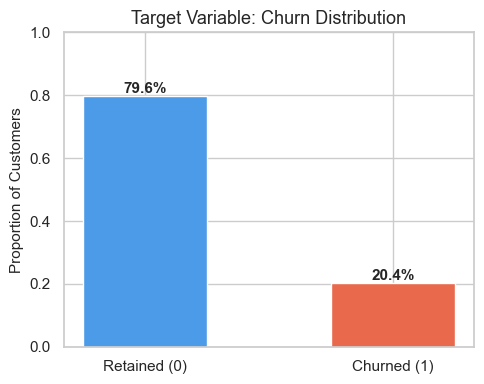

Churn rate: 20.4%  |  Class imbalance ratio ~3.9:1


In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
churn_rate = churn_df["Exited"].value_counts(normalize=True)

bars = ax.bar(
    ["Retained (0)", "Churned (1)"],
    churn_rate.values,
    color=["#4C9BE8", "#E8694C"], width=0.5
)
for bar, val in zip(bars, churn_rate.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", fontsize=11, fontweight="bold")

ax.set_ylim(0, 1)
ax.set_ylabel("Proportion of Customers")
ax.set_title("Target Variable: Churn Distribution")
plt.tight_layout()
plt.show()

print(f"Churn rate: {churn_rate[1]:.1%}  |  Class imbalance ratio ~{churn_rate[0]/churn_rate[1]:.1f}:1")


**Observation:** The dataset is **imbalanced** — roughly 20% churned. Raw accuracy will be misleading; we should prioritise **Recall** (catching actual churners) and **F1-score**.

> ⚠️ **Assumption:** The ~20% churn rate reflects the true population rate. If this dataset was constructed by oversampling churners (common in banking datasets), the apparent rate overstates reality and recall targets should be adjusted accordingly.


### 3.2 · Categorical Features vs Churn

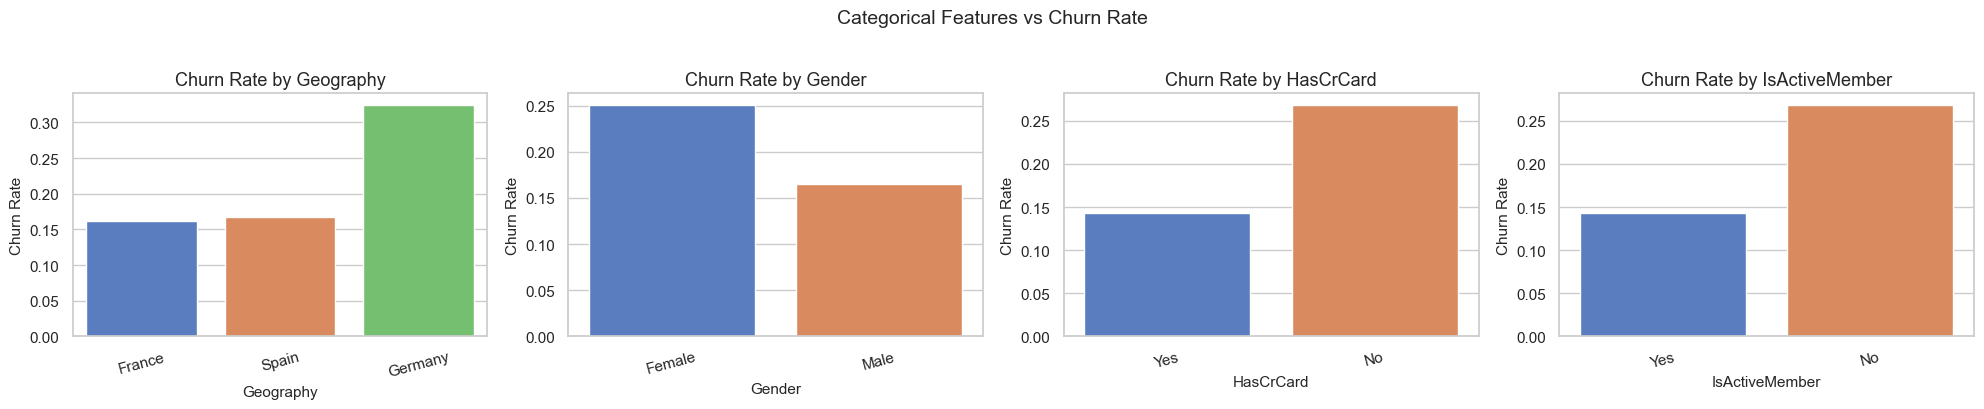

In [17]:
cat_cols = churn_df.drop("Surname", axis=1).select_dtypes("object").columns.tolist()

fig, axes = plt.subplots(1, len(cat_cols), figsize=(5 * len(cat_cols), 4))
if len(cat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, cat_cols):
    sns.barplot(data=churn_df, x=col, y="Exited", ax=ax, palette="muted", ci=None)
    ax.set_title(f"Churn Rate by {col}")
    ax.set_ylabel("Churn Rate")
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Categorical Features vs Churn Rate", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Key Observations:**
- **Geography:** German customers churn at a noticeably higher rate — worth investigating with the business
- **Gender:** Female customers churn slightly more than male customers

> ⚠️ **Caveat:** These are univariate relationships. Geography and Gender may be confounded with other variables (e.g. balance). Use model coefficients for adjusted estimates.


### 3.3 · Numeric Features vs Churn

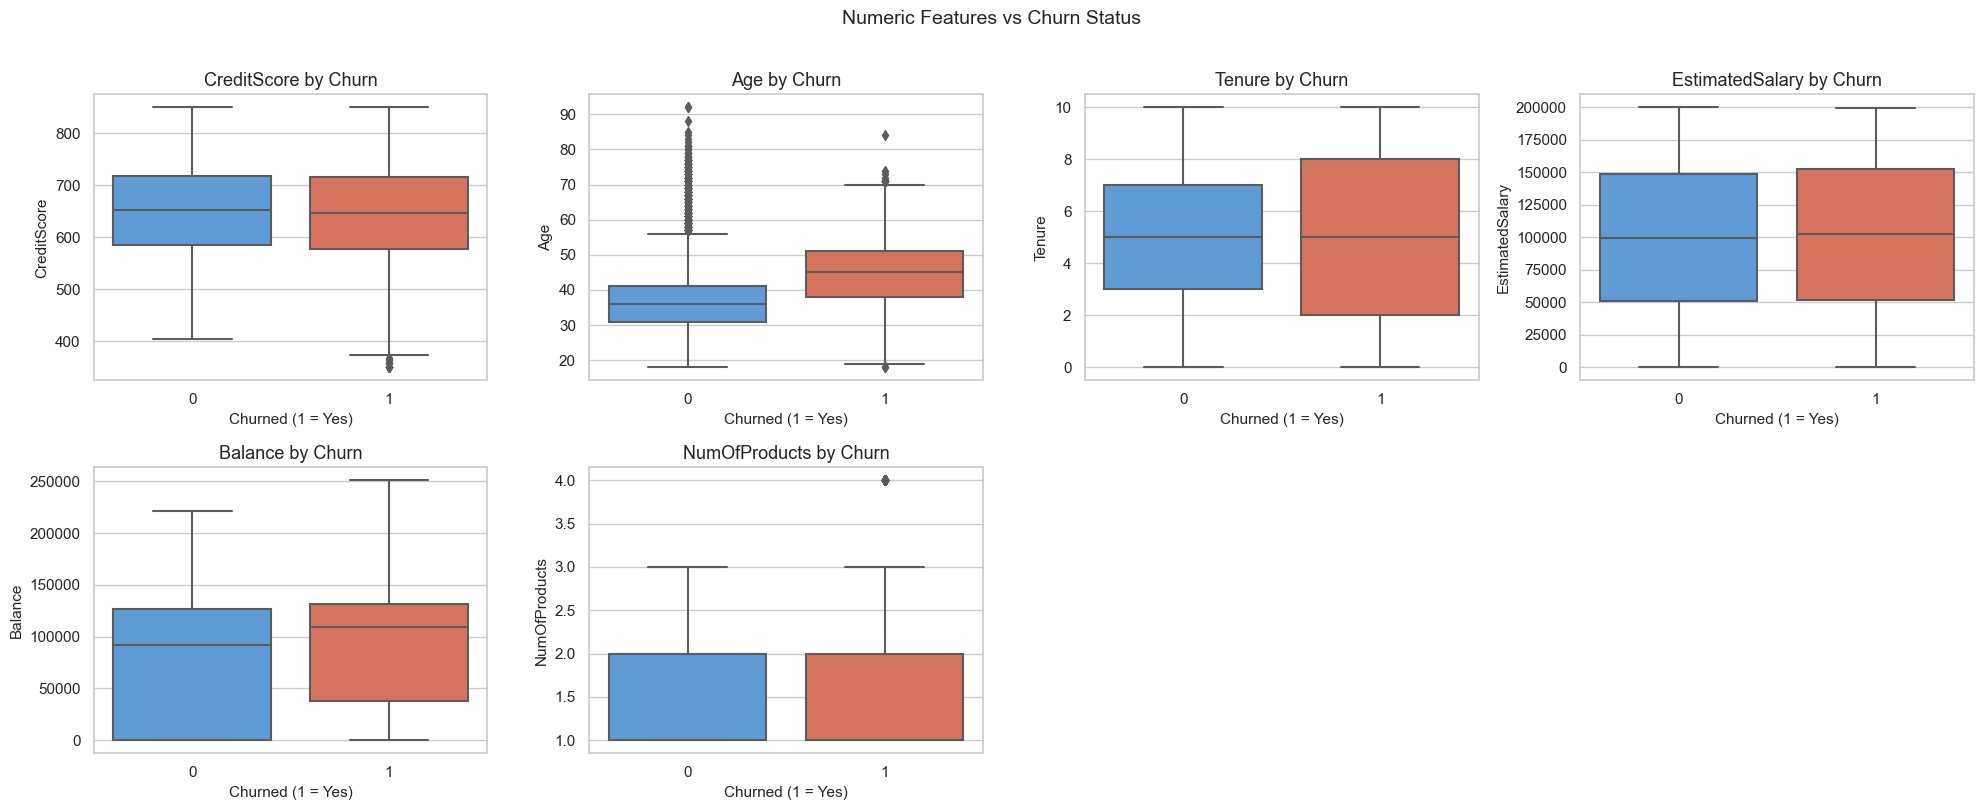

In [18]:
num_cols = churn_df.drop(["CustomerId", "Exited"], axis=1).select_dtypes("number").columns.tolist()
n = len(num_cols)
ncols, nrows = 4, -(-n // 4)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.boxplot(data=churn_df, y=col, x="Exited", ax=ax,
                palette={0: "#4C9BE8", 1: "#E8694C"})
    ax.set_title(f"{col} by Churn")
    ax.set_xlabel("Churned (1 = Yes)")

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Numeric Features vs Churn Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


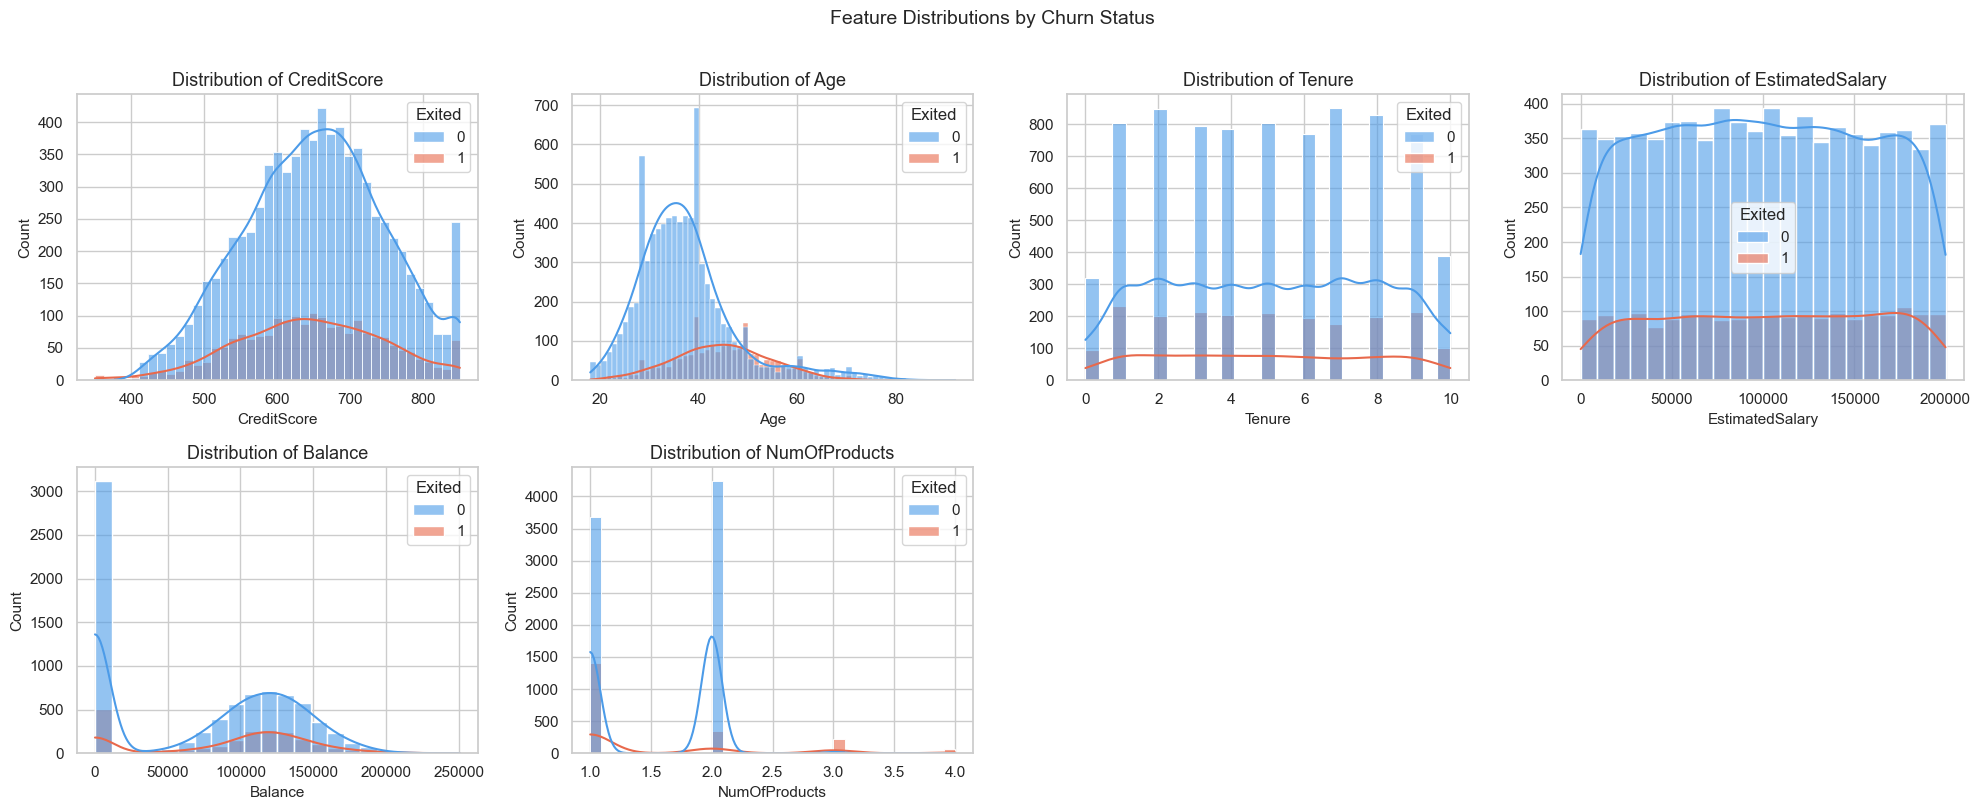

In [19]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, num_cols):
    sns.histplot(data=churn_df, x=col, hue="Exited", kde=True, ax=ax,
                 palette={0: "#4C9BE8", 1: "#E8694C"}, alpha=0.6)
    ax.set_title(f"Distribution of {col}")

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle("Feature Distributions by Churn Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


### 3.4 · Correlation Heatmap

Checking for multicollinearity — high correlation between predictors can destabilise logistic regression coefficients.

> ⚠️ **Assumption:** Pearson correlation captures only **linear** relationships. Non-linear feature dependencies will not be reflected here.


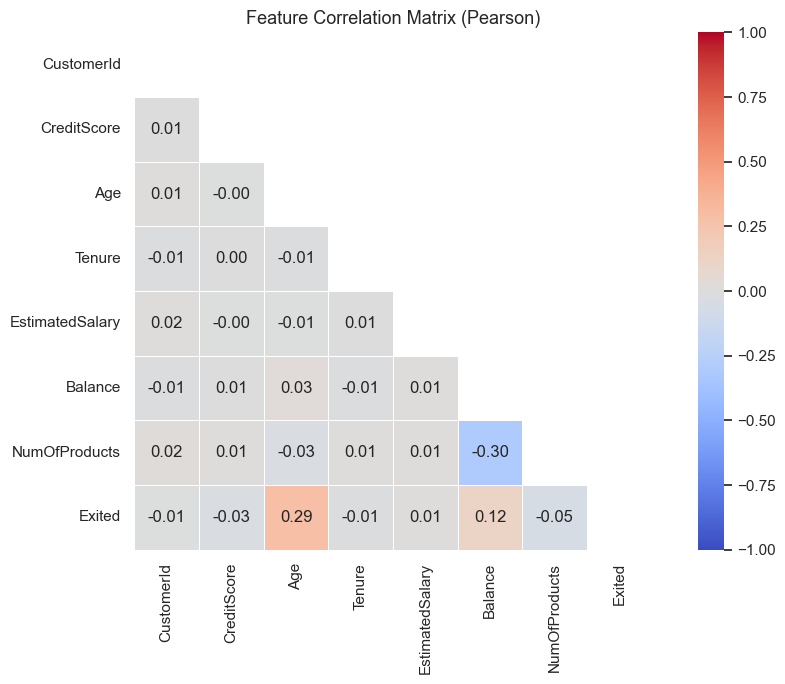

In [20]:
corr = churn_df.select_dtypes("number").corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, ax=ax, vmin=-1, vmax=1, cmap="coolwarm",
            annot=True, fmt=".2f", square=True, linewidths=0.5)
ax.set_title("Feature Correlation Matrix (Pearson)", fontsize=13)
plt.tight_layout()
plt.show()


**Observation:** No feature pairs exceed 0.7 correlation — no major multicollinearity concerns. All features can be safely retained for modelling.


---
## 4 · Feature Engineering & Data Preparation

Two domain-inspired features are created before modelling:

| Feature | Formula | Intuition |
|---------|---------|-----------|
| `balance_to_income` | `Balance / EstimatedSalary` | Relative wealth proxy — high balance relative to income may indicate financial sophistication |
| `income_v_product` | `EstimatedSalary / NumOfProducts` | Revenue per product — high values may indicate underserved, high-value customers |

> ⚠️ **Caveat:** `EstimatedSalary` is a modelled estimate, not verified income. Ratio features derived from it are directional proxies, not precise measurements.


In [21]:
modelling_df = churn_df.drop(["CustomerId", "Surname"], axis=1)

modelling_df = modelling_df.assign(
    balance_to_income = modelling_df["Balance"] / modelling_df["EstimatedSalary"],
    income_v_product  = modelling_df["EstimatedSalary"] / modelling_df["NumOfProducts"]
)

print(f"Modelling dataframe: {modelling_df.shape[0]:,} rows x {modelling_df.shape[1]} cols")
modelling_df[["balance_to_income", "income_v_product"]].describe().round(3)


Modelling dataframe: 10,000 rows x 13 cols


,balance_to_income,income_v_product
count,10000.000,10000.000
mean,3.879,74717.171
std,108.337,52059.498
min,0.000,11.580
25%,0.000,32589.780
50%,0.747,65908.002
75%,1.514,100943.798
max,10614.655,199970.740


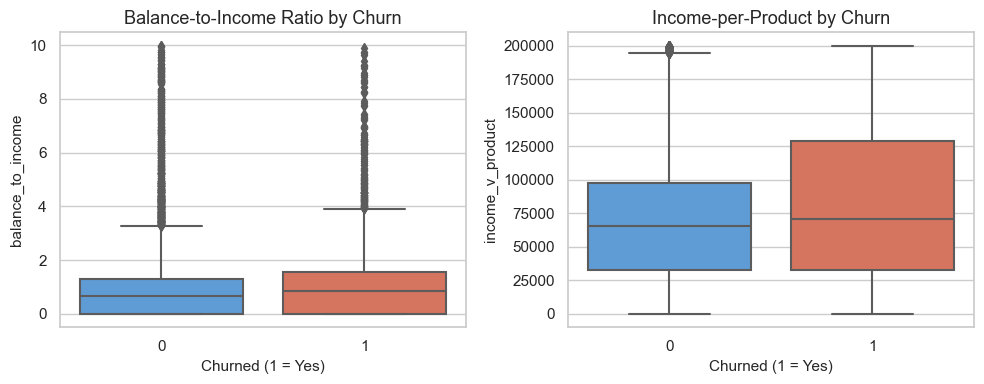

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(data=modelling_df.query("balance_to_income < 10"),
            y="balance_to_income", x="Exited",
            palette={0: "#4C9BE8", 1: "#E8694C"}, ax=axes[0])
axes[0].set_title("Balance-to-Income Ratio by Churn")
axes[0].set_xlabel("Churned (1 = Yes)")

sns.boxplot(data=modelling_df, y="income_v_product", x="Exited",
            palette={0: "#4C9BE8", 1: "#E8694C"}, ax=axes[1])
axes[1].set_title("Income-per-Product by Churn")
axes[1].set_xlabel("Churned (1 = Yes)")

plt.tight_layout()
plt.show()


In [23]:
# One-hot encode categorical columns — drop_first avoids the dummy variable trap
modelling_df = pd.get_dummies(modelling_df, drop_first=True, dtype="int")
print(f"Post-encoding shape: {modelling_df.shape}")
modelling_df.head(3)


Post-encoding shape: (10000, 14)


,CreditScore,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,Exited,balance_to_income,income_v_product,Geography_Germany,Geography_Spain,Gender_Male,HasCrCard_Yes,IsActiveMember_Yes
0,619,42.0,2,101348.88,0.00,1,1,0.000000,101348.88,0,0,0,1,1
2,608,41.0,1,112542.58,83807.86,1,0,0.744677,112542.58,0,1,0,1,1
3,502,42.0,8,113931.57,159660.80,3,1,1.401375,37977.19,0,0,0,0,0


---
## 5 · Train–Test Split

An **80/20 split** with a fixed `random_state` for reproducibility.

> ⚠️ **Assumption:** `train_test_split` shuffles rows randomly, which assumes rows are **i.i.d.** If the data has temporal ordering (recent customers differ from older ones), a time-based split would be more appropriate to avoid data leakage.


In [24]:
from sklearn.model_selection import train_test_split

X = modelling_df.drop("Exited", axis=1)
y = modelling_df["Exited"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=2024)

print(f"Training set:  {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X):.0%})")
print(f"Test set:      {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X):.0%})")
print(f"Features:      {X_train.shape[1]}")
print(f"Churn rate — Train: {Y_train.mean():.1%}  |  Test: {Y_test.mean():.1%}")


Training set:  8,000 rows (80%)
Test set:      2,000 rows  (20%)
Features:      13
Churn rate — Train: 20.3%  |  Test: 20.4%


---
## 6 · Baseline Model: Logistic Regression

Logistic Regression models the **log-odds of churn** as a linear combination of features — making coefficients directly interpretable as churn drivers.

> ⚠️ **Key assumptions:**
> - Linear relationship between features and the **log-odds** of churn (not the outcome itself)
> - No severe multicollinearity between predictors
> - Observations are independent
> - Sufficient sample size relative to the number of features


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

lr = LogisticRegression(solver="newton-cg", max_iter=500, random_state=42)
lr.fit(X_train, Y_train)

print("Training Performance")
print(f"  Accuracy:  {lr.score(X_train, Y_train):.4f}")
print(f"  Precision: {precision_score(Y_train, lr.predict(X_train)):.4f}")
print(f"  Recall:    {recall_score(Y_train, lr.predict(X_train)):.4f}")
print(f"  F1 Score:  {f1_score(Y_train, lr.predict(X_train)):.4f}")


C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:478: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:327: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:478: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:327: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:478: LineSearchWarning: The line search algorithm did not converge
  warn('The line 

Training Performance
  Accuracy:  0.8173
  Precision: 0.6224
  Recall:    0.2592
  F1 Score:  0.3660


C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:478: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:327: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:437: LineSearchWarning: Rounding errors prevent the line search from converging
  warn(msg, LineSearchWarning)
C:\Users\debad\anaconda3\lib\site-packages\scipy\optimize\linesearch.py:327: LineSearchWarning: The line search algorithm did not converge
  warn('The line search algorithm did not converge', LineSearchWarning)
C:\Users\debad\anaconda3\lib\site-packages\sklearn\utils\optimize.py:203: UserWarning: Line Search failed
  warnings.warn("Line Search failed")


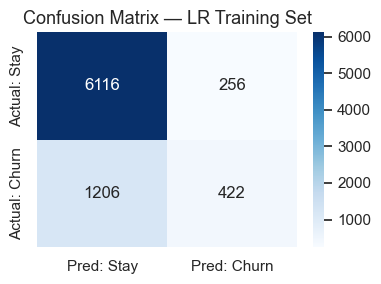

In [26]:
cm_train = confusion_matrix(Y_train, lr.predict(X_train))

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_train, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred: Stay", "Pred: Churn"],
            yticklabels=["Actual: Stay", "Actual: Churn"])
ax.set_title("Confusion Matrix — LR Training Set")
plt.tight_layout()
plt.show()


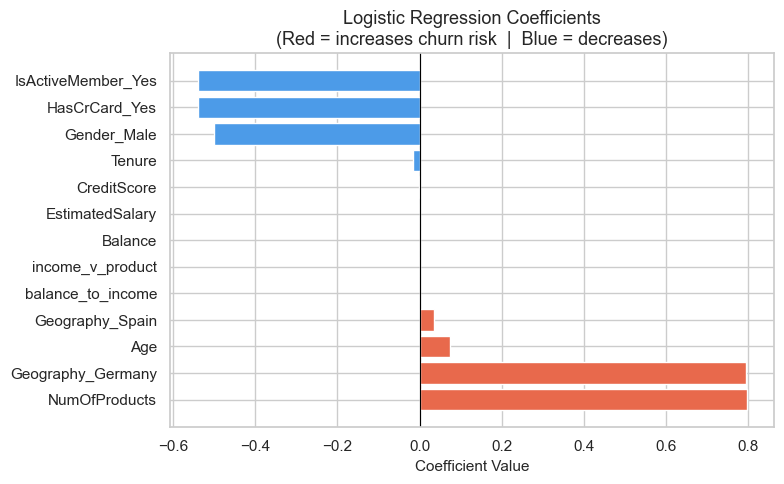

In [27]:
# Feature coefficients — which features drive churn risk?
coef_df = (
    pd.DataFrame({"feature": X_train.columns, "coefficient": lr.coef_[0]})
    .sort_values("coefficient", ascending=False)
)

colors = ["#E8694C" if c > 0 else "#4C9BE8" for c in coef_df["coefficient"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(coef_df["feature"], coef_df["coefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Coefficients\n(Red = increases churn risk  |  Blue = decreases)")
ax.set_xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


### 6.1 · Test Set Evaluation

Test Set Performance
  Accuracy:  0.8115
  Precision: 0.6111
  Recall:    0.2152
  F1 Score:  0.3183


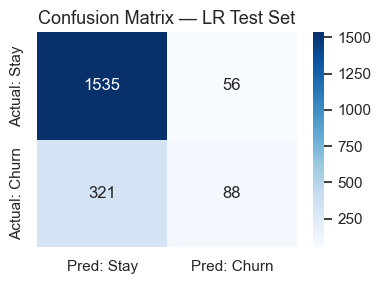

In [28]:
print("Test Set Performance")
print(f"  Accuracy:  {lr.score(X_test, Y_test):.4f}")
print(f"  Precision: {precision_score(Y_test, lr.predict(X_test)):.4f}")
print(f"  Recall:    {recall_score(Y_test, lr.predict(X_test)):.4f}")
print(f"  F1 Score:  {f1_score(Y_test, lr.predict(X_test)):.4f}")

cm_test = confusion_matrix(Y_test, lr.predict(X_test))
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Pred: Stay", "Pred: Churn"],
            yticklabels=["Actual: Stay", "Actual: Churn"])
ax.set_title("Confusion Matrix — LR Test Set")
plt.tight_layout()
plt.show()


**Observation:** Train vs. test performance is similar — the model is **not significantly overfit**. However, **Recall on churners is low**. Since missing a churner is more costly than a false alarm in retention campaigns, we should adjust the decision threshold.


### 6.2 · ROC Curve & AUC

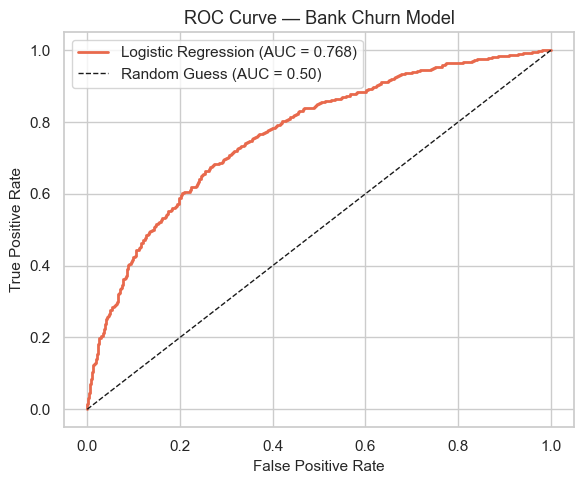

AUC: 0.7680


In [29]:
from sklearn.metrics import roc_curve, auc

y_probs_lr = lr.predict_proba(X_test)[:, 1]
fpr1, tpr1, _ = roc_curve(Y_test, y_probs_lr)
auc_lr = auc(fpr1, tpr1)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr1, tpr1, color="#E8694C", lw=2, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guess (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Bank Churn Model")
ax.legend()
plt.tight_layout()
plt.show()
print(f"AUC: {auc_lr:.4f}")


### 6.3 · Precision–Recall Threshold Optimisation

The default decision threshold in sklearn is **0.5**. Lowering it catches more churners (higher Recall) at the cost of more false positives (lower Precision).

**Business framing:** If the cost of a retention campaign per customer is small relative to the lifetime value of a saved customer, it is acceptable to sacrifice Precision for Recall. The threshold choice should be made in consultation with the business team.


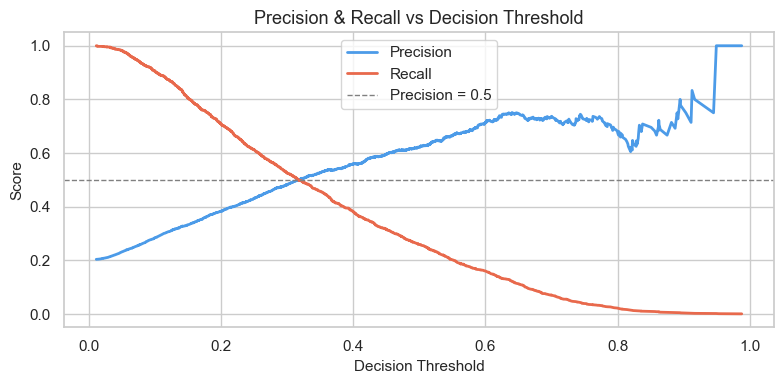

In [30]:
from sklearn.metrics import precision_recall_curve

p_curve, r_curve, t_curve = precision_recall_curve(Y_train, lr.predict_proba(X_train)[:, 1])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_curve, p_curve[:-1], color="#4C9BE8", label="Precision", lw=2)
ax.plot(t_curve, r_curve[:-1], color="#E8694C", label="Recall", lw=2)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Precision = 0.5")
ax.set_xlabel("Decision Threshold")
ax.set_ylabel("Score")
ax.set_title("Precision & Recall vs Decision Threshold")
ax.legend()
plt.tight_layout()
plt.show()


In [33]:
# Find the optimal threshold: maximum recall while keeping precision >= 0.5
# p_curve has len(t_curve) + 1 elements — trim the last value to align
p_aligned = p_curve[:-1]

indices_above_50 = np.where(p_aligned >= 0.5)[0]
optimal_threshold = t_curve[indices_above_50[-1]]

print(f"Optimal threshold (max recall | precision >= 0.5): {optimal_threshold:.3f}")


Optimal threshold (max recall | precision >= 0.5): 0.988


Performance at threshold = 0.34
  Precision: 0.5198
  Recall:    0.4181
  F1 Score:  0.4634


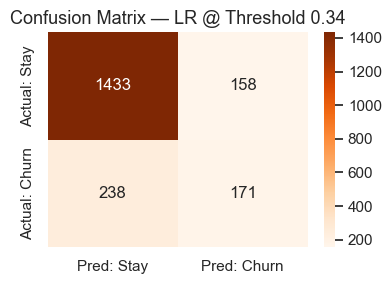

In [35]:
optimal_threshold= 0.34
y_pred_opt = lr.predict_proba(X_test)[:, 1] > optimal_threshold

print(f"Performance at threshold = {optimal_threshold:.2f}")
print(f"  Precision: {precision_score(Y_test, y_pred_opt):.4f}")
print(f"  Recall:    {recall_score(Y_test, y_pred_opt):.4f}")
print(f"  F1 Score:  {f1_score(Y_test, y_pred_opt):.4f}")

cm_opt = confusion_matrix(Y_test, y_pred_opt)
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Oranges", ax=ax,
            xticklabels=["Pred: Stay", "Pred: Churn"],
            yticklabels=["Actual: Stay", "Actual: Churn"])
ax.set_title(f"Confusion Matrix — LR @ Threshold {optimal_threshold:.2f}")
plt.tight_layout()
plt.show()


**Takeaway:** The lowered threshold significantly improves Recall. The right balance depends on the **cost of a missed churner vs. the cost of a wasted retention offer** — a conversation to have with the business team before deployment.


---
## 7 · Improved Model: Random Forest (Tuned)

Random Forests are **ensemble models** that average predictions from many decision trees trained on bootstrapped samples — reducing variance compared to a single tree.

**Advantages over Logistic Regression:**
- Handles non-linear feature interactions automatically
- Less sensitive to feature scaling
- Provides feature importance estimates

> ⚠️ **Key caveats:**
> - An untuned Random Forest will **overfit** severely — hyperparameter tuning is essential
> - Feature importances measure **impurity reduction**, not causal importance. Correlated features share importance, which can be misleading
> - Random Forests are less interpretable than Logistic Regression — consider SHAP values for explainability requirements


In [36]:
from sklearn.ensemble import RandomForestClassifier

# Step 1: Untuned baseline — confirm overfitting
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, Y_train)

print("Untuned Random Forest")
print(f"  Train Accuracy: {rf_base.score(X_train, Y_train):.4f}  <- likely overfit")
print(f"  Test Accuracy:  {rf_base.score(X_test, Y_test):.4f}")
print(f"\nLogistic Regression (for comparison)")
print(f"  Train Accuracy: {lr.score(X_train, Y_train):.4f}")
print(f"  Test Accuracy:  {lr.score(X_test, Y_test):.4f}")


Untuned Random Forest
  Train Accuracy: 1.0000  <- likely overfit
  Test Accuracy:  0.8575

Logistic Regression (for comparison)
  Train Accuracy: 0.8173
  Test Accuracy:  0.8115


In [37]:
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier(random_state=2023, n_jobs=-1)

param_grid_random = {
    "n_estimators":     np.arange(100, 1100, 100),
    "max_features":     [None, "sqrt"],
    "bootstrap":        [True],
    "max_samples":      [None, 0.2, 0.5, 0.9],
    "max_depth":        np.arange(1, 11),
    "min_samples_leaf": [2, 5, 10, 20, 100],
}

random_search = RandomizedSearchCV(
    rf,
    param_grid_random,
    n_iter=100,
    scoring="accuracy",
    cv=3, 
    random_state=42,
    n_jobs=-1, 
    verbose=1
)
random_search.fit(X_train, Y_train)
print("\nBest params from RandomizedSearchCV:")
print(random_search.best_params_)


Fitting 3 folds for each of 100 candidates, totalling 300 fits

Best params from RandomizedSearchCV:
{'n_estimators': 1000, 'min_samples_leaf': 10, 'max_samples': 0.9, 'max_features': None, 'max_depth': 9, 'bootstrap': True}


In [41]:
from sklearn.model_selection import GridSearchCV

param_grid_fine = {
    "n_estimators":     np.arange(100, 1100, 100),
    "max_samples":      [None, 0.2, 1.2],
    "max_depth":        [8, 10, 12],
    "min_samples_leaf": [1, 2, 7],
}

grid_search = GridSearchCV(
                           rf,
                           param_grid_fine, 
                           scoring="accuracy",
                           cv=3,
                           n_jobs=-1,
                           verbose=1)
grid_search.fit(X_train, Y_train)
print("\nBest params from GridSearchCV:")
print(grid_search.best_params_)


Fitting 3 folds for each of 270 candidates, totalling 810 fits


C:\Users\debad\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py:372: FitFailedWarning: 
270 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
270 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\debad\anaconda3\lib\site-packages\sklearn\model_selection\_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\debad\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py", line 385, in fit
    n_samples_bootstrap = _get_n_samples_bootstrap(
  File "C:\Users\debad\anaconda3\lib\site-packages\sklearn\ensemble\_forest.py", line 117, in _get_n_samples_bootstrap
    raise ValueError(msg.format(max_sa


Best params from GridSearchCV:
{'max_depth': 10, 'max_samples': None, 'min_samples_leaf': 2, 'n_estimators': 100}


In [42]:
# Train final tuned model with best hyperparameters
rf_tuned = RandomForestClassifier(
    n_estimators=100,
    bootstrap=True, 
    max_samples=0.2,
    max_depth=10, 
    min_samples_leaf=2, 
    random_state=42, 
    n_jobs=-1
)
rf_tuned.fit(X_train, Y_train)

print("Tuned Random Forest Performance")
print(f"  Train Accuracy: {rf_tuned.score(X_train, Y_train):.4f}")
print(f"  Test Accuracy:  {rf_tuned.score(X_test, Y_test):.4f}")
print(f"  Precision:      {precision_score(Y_test, rf_tuned.predict(X_test)):.4f}")
print(f"  Recall:         {recall_score(Y_test, rf_tuned.predict(X_test)):.4f}")
print(f"  F1 Score:       {f1_score(Y_test, rf_tuned.predict(X_test)):.4f}")


Tuned Random Forest Performance
  Train Accuracy: 0.8780
  Test Accuracy:  0.8545
  Precision:      0.8041
  Recall:         0.3814
  F1 Score:       0.5174


### 7.1 · ROC Curve Comparison

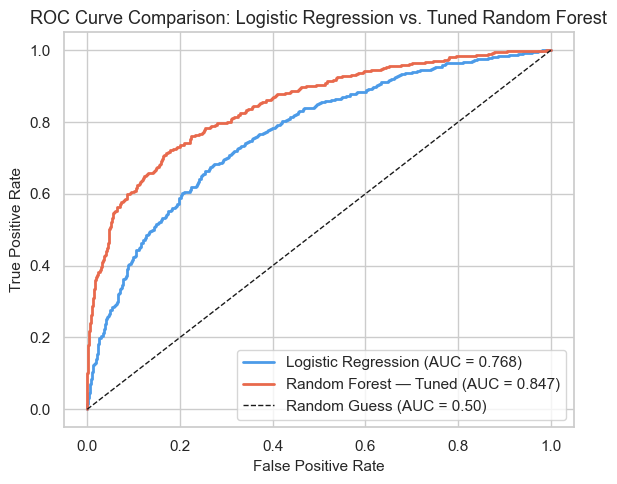

In [43]:
y_probs_rf = rf_tuned.predict_proba(X_test)[:, 1]
fpr2, tpr2, _ = roc_curve(Y_test, y_probs_rf)
auc_rf = auc(fpr2, tpr2)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr1, tpr1, color="#4C9BE8", lw=2, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
ax.plot(fpr2, tpr2, color="#E8694C", lw=2, label=f"Random Forest — Tuned (AUC = {auc_rf:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Guess (AUC = 0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison: Logistic Regression vs. Tuned Random Forest")
ax.legend()
plt.tight_layout()
plt.show()


### 7.2 · Feature Importance

> ⚠️ **Caveat on Gini importance:** It can be biased toward high-cardinality features (e.g. `Balance`, `Age`). For more reliable estimates, consider **permutation importance** or **SHAP values**.


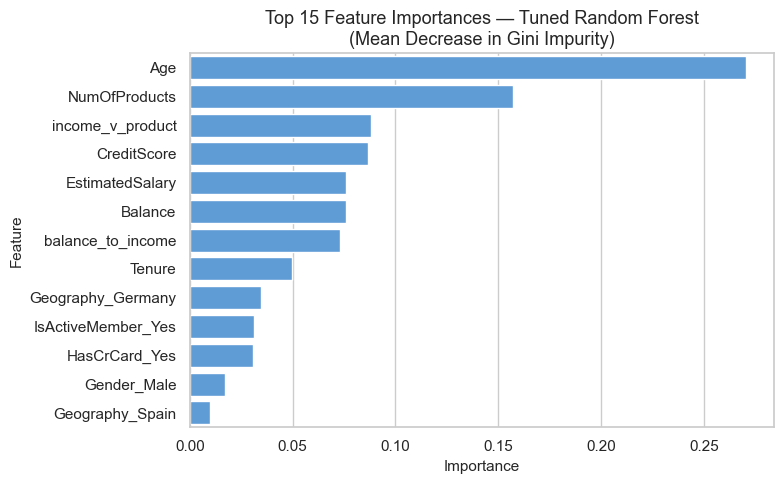

Top 5 most important features:
         feature  importance
             Age    0.270440
   NumOfProducts    0.156969
income_v_product    0.087953
     CreditScore    0.086673
 EstimatedSalary    0.076022


In [44]:
importance_df = (
    pd.DataFrame({"feature": X_train.columns, "importance": rf_tuned.feature_importances_})
    .sort_values("importance", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_df, x="importance", y="feature", ax=ax, color="#4C9BE8")
ax.set_title("Top 15 Feature Importances — Tuned Random Forest\n(Mean Decrease in Gini Impurity)")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(importance_df.head(5).to_string(index=False))


![Bank Customer Insights](clusterimage.png)

---
## 8 · Customer Segmentation: K-Means Clustering

Beyond predicting *who* will churn, the product team wants to understand *what kinds of customers* they have — so they can tailor offerings to each group.

We use **K-Means clustering** to partition customers into *k* groups based on feature similarity.

> ⚠️ **Key assumptions of K-Means:**
> - Features must be **standardised** — K-Means uses Euclidean distance, so large-scale features will dominate
> - Assumes clusters are **spherical and roughly equal-sized** — non-convex shapes will be misidentified
> - Sensitive to **outliers** and initial centroid positions (mitigated by `n_init=10`)
> - The "correct" *k* is not mathematically determined — it requires domain judgement alongside the elbow plot


### 8.1 · Prepare Clustering Data

In [45]:
cluster_df = churn_df.drop(["CustomerId", "Surname", "Exited"], axis=1).reset_index(drop=True)

# Encode binary categoricals
cluster_df["Gender"]         = np.where(cluster_df["Gender"] == "Female", 1, 0)
cluster_df["HasCrCard"]      = np.where(cluster_df["HasCrCard"] == "Yes", 1, 0)
cluster_df["IsActiveMember"] = np.where(cluster_df["IsActiveMember"] == "Yes", 1, 0)

cluster_df = pd.get_dummies(cluster_df, columns=["Geography"], dtype="int", prefix="", prefix_sep="")

# Engineered feature: products per year of tenure (handle zero-tenure edge case)
cluster_df["ProductsPerYear"] = np.where(
    cluster_df["Tenure"] == 0,
    cluster_df["NumOfProducts"],
    cluster_df["NumOfProducts"] / cluster_df["Tenure"]
)

print(f"Clustering dataset: {cluster_df.shape[0]:,} rows x {cluster_df.shape[1]} cols")
cluster_df.head(3)


Clustering dataset: 10,000 rows x 13 cols


,CreditScore,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,France,Germany,Spain,ProductsPerYear
0,619,1,42.0,2,101348.88,0.00,1,1,1,1,0,0,0.500
1,608,1,41.0,1,112542.58,83807.86,1,1,1,0,0,1,1.000
2,502,1,42.0,8,113931.57,159660.80,3,0,0,1,0,0,0.375


In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
cluster_df_scaled = pd.DataFrame(scaler.fit_transform(cluster_df), columns=cluster_df.columns)

print("Post-scaling stats (should be ~0 mean, ~1 std per feature):")
cluster_df_scaled.describe().loc[["mean", "std"]].round(2)


Post-scaling stats (should be ~0 mean, ~1 std per feature):


,CreditScore,Gender,Age,Tenure,EstimatedSalary,Balance,NumOfProducts,HasCrCard,IsActiveMember,France,Germany,Spain,ProductsPerYear
mean,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 8.2 · Choosing the Number of Clusters

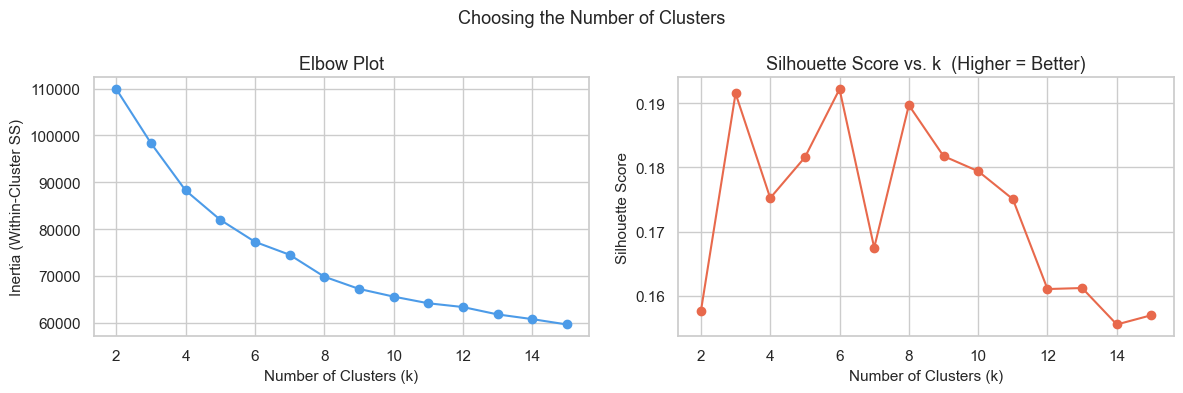

In [47]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia_values    = []
silhouette_scores = []
k_range           = range(2, 16)

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(cluster_df_scaled)
    inertia_values.append(km.inertia_)
    silhouette_scores.append(silhouette_score(cluster_df_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(list(k_range), inertia_values, marker="o", color="#4C9BE8")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia (Within-Cluster SS)")
ax1.set_title("Elbow Plot")

ax2.plot(list(k_range), silhouette_scores, marker="o", color="#E8694C")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Score vs. k  (Higher = Better)")

plt.suptitle("Choosing the Number of Clusters", fontsize=13)
plt.tight_layout()
plt.show()


**Interpretation:** Combine the elbow (point where inertia stops decreasing sharply) with the silhouette score (higher = better separated clusters) to choose *k*.

> ⚠️ The elbow method is subjective. The best *k* balances statistical guidance with whether resulting clusters are **actionable and interpretable** for the business.


### 8.3 · Round 1 — Clustering with Geography (k=5)

In [48]:
from collections import Counter

kmeans5 = KMeans(n_clusters=5, n_init=10, random_state=42)
kmeans5.fit(cluster_df_scaled)

print("Customers per cluster:")
for c, n in sorted(Counter(kmeans5.labels_).items()):
    print(f"  Cluster {c}: {n:,} customers")


Customers per cluster:
  Cluster 0: 2,336 customers
  Cluster 1: 2,392 customers
  Cluster 2: 686 customers
  Cluster 3: 2,329 customers
  Cluster 4: 2,257 customers


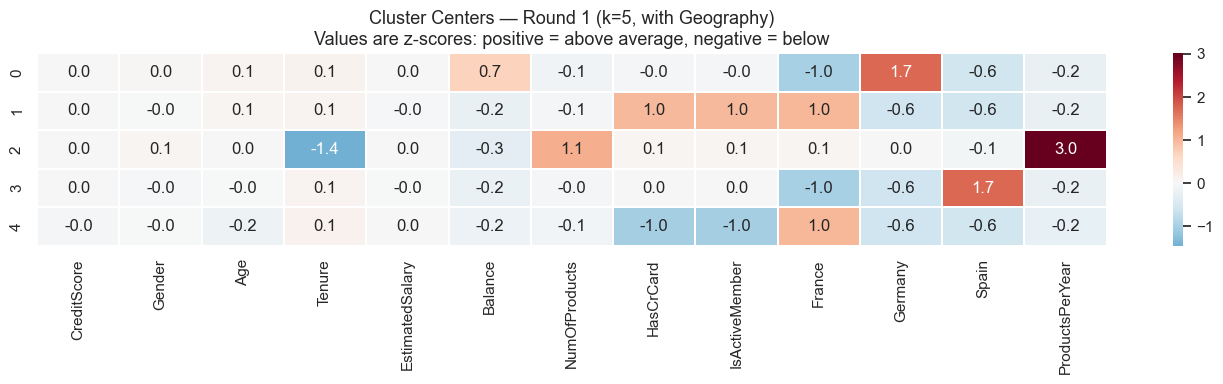

In [49]:
cluster_centers5 = pd.DataFrame(kmeans5.cluster_centers_, columns=cluster_df_scaled.columns)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(cluster_centers5, ax=ax, annot=True, cmap="RdBu_r",
            fmt=".1f", linewidths=0.3, center=0)
ax.set_title("Cluster Centers — Round 1 (k=5, with Geography)\n"
             "Values are z-scores: positive = above average, negative = below")
plt.tight_layout()
plt.show()


**Cluster Profiles (Round 1):**

| Cluster | Key Characteristics |
|---------|---------------------|
| 0 | High `Spain` flag, low products, low balance |
| 1 | High `France` flag, active member, low products |
| 2 | High `France` flag, low activity |
| 3 | High product count, low tenure — new multi-product customers |
| 4 | High `Germany` flag, high balance |

**Problem:** Most clusters are dominated by **geography** rather than behavioural signals. We remove geography and re-cluster to surface more actionable segments.


### 8.4 · Round 2 — Clustering without Geography (k=4)

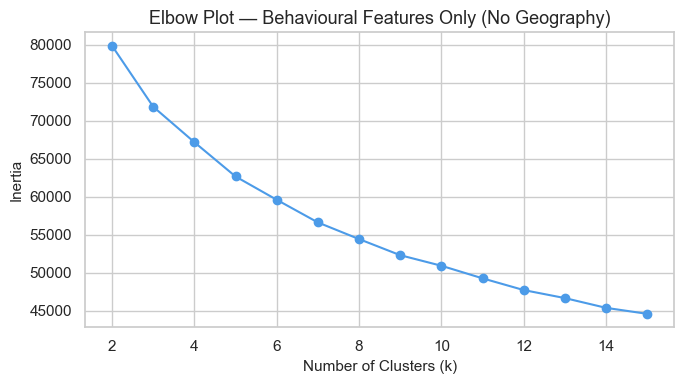

In [50]:
geo_cols = [col for col in cluster_df_scaled.columns if col in ["France", "Germany", "Spain"]]
df_no_geo = cluster_df_scaled.drop(geo_cols, axis=1)

# Check the elbow plot on the no-geo features
inertia_no_geo = []
for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(df_no_geo)
    inertia_no_geo.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
pd.Series(inertia_no_geo, index=list(k_range)).plot(marker="o", ax=ax, color="#4C9BE8")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Plot — Behavioural Features Only (No Geography)")
plt.tight_layout()
plt.show()


In [51]:
# Inspect the geographical balance distributions to confirm geography was dominant
print("Average balance by country (before removing geography):")
print(churn_df.groupby("Geography")["Balance"].describe().round(0).to_string())


Average balance by country (before removing geography):
            count      mean      std      min       25%       50%       75%       max
Geography                                                                            
France     5014.0   62093.0  64134.0      0.0       0.0   62154.0  121445.0  238388.0
Germany    2509.0  119730.0  27022.0  27288.0  102801.0  119703.0  137560.0  214347.0
Spain      2477.0   61818.0  64236.0      0.0       0.0   61710.0  121057.0  250898.0


In [52]:
kmeans4 = KMeans(n_clusters=4, n_init=10, random_state=42)
kmeans4.fit(df_no_geo)

print("Customers per cluster:")
for c, n in sorted(Counter(kmeans4.labels_).items()):
    print(f"  Cluster {c}: {n:,} customers")


Customers per cluster:
  Cluster 0: 709 customers
  Cluster 1: 4,521 customers
  Cluster 2: 1,943 customers
  Cluster 3: 2,827 customers


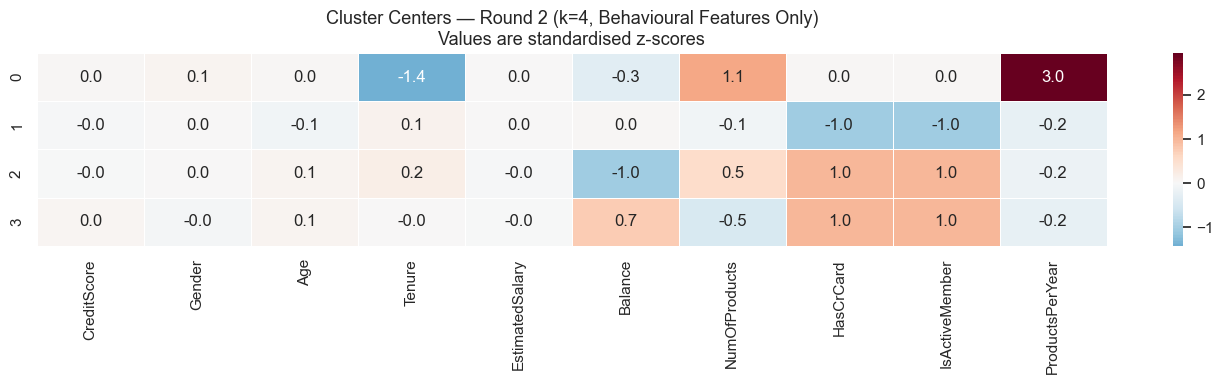

In [53]:
cluster_centers4 = pd.DataFrame(kmeans4.cluster_centers_, columns=df_no_geo.columns)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(cluster_centers4, ax=ax, annot=True, cmap="RdBu_r",
            fmt=".1f", linewidths=0.5, center=0)
ax.set_title("Cluster Centers — Round 2 (k=4, Behavioural Features Only)\n"
             "Values are standardised z-scores")
plt.tight_layout()
plt.show()


**Cluster Profiles (Round 2):**

| Cluster | Key Characteristics | Interpretation |
|---------|--------------------|-|
| 0 | High products, low tenure | New multi-product customers |
| 1 | High balance, has credit card, low products | Wealthy but underserved — prime upsell targets |
| 2 | No credit card, low products | Entry-level, low-engagement customers |
| 3 | Low balance, has credit card, more products | Active, moderate-balance customers |


### 8.5 · Churn Rate by Cluster

In [54]:
data_final = pd.concat([
    cluster_df,
    churn_df["Exited"].reset_index(drop=True),
    pd.Series(kmeans4.labels_, name="Cluster")
], axis=1)

cluster_summary = (
    data_final.groupby("Cluster")
    .agg(
        n_customers    = ("Exited", "count"),
        churn_rate     = ("Exited", "mean"),
        avg_balance    = ("Balance", "mean"),
        avg_products   = ("NumOfProducts", "mean"),
        pct_active     = ("IsActiveMember", "mean"),
        pct_has_card   = ("HasCrCard", "mean")
    )
    .round(3)
)

print("Cluster Summary:")
print(cluster_summary.to_string())


Cluster Summary:
         n_customers  churn_rate  avg_balance  avg_products  pct_active  pct_has_card
Cluster                                                                              
0                709       0.210    56731.124         2.189       0.537         0.537
1               4521       0.268    79010.783         1.471       0.000         0.000
2               1943       0.122    11269.554         1.835       1.000         1.000
3               2827       0.155   122225.692         1.250       1.000         1.000


---
## 9 · Recommendations

Based on both the churn model and customer segmentation:

---

### 🎯 Model-Level Recommendations

| Action | Rationale |
|--------|-----------|
| Deploy the **tuned Random Forest** for churn scoring | Higher AUC than Logistic Regression; captures non-linear patterns |
| Use a **lowered decision threshold (~0.34)** for retention campaigns | Maximises recall while keeping precision above 50% |
| Trigger outreach when churn probability exceeds threshold | Enables proactive intervention before the customer leaves |

---

### 👥 Segment-Level Recommendations

| Cluster | Profile | Recommended Action |
|---------|---------|-------------------|
| **Cluster 1** — High Balance, Low Products | Wealthy but underserved | Offer premium investment or wealth management products; personalised advisor sessions |
| **Cluster 2** — Highest Churn, High Balance | High-value, disengaged | Priority retention — loyalty rewards, dedicated relationship manager, or exclusive perks |
| **Cluster 3** — No Credit Card, Low Products | Entry-level customers | Offer an entry-level credit card; financial literacy content to build engagement |
| **Cluster 0** — High Products, Low Tenure | New power-users | Reward early engagement; tenure milestone benefits to encourage long-term loyalty |

---

### 📋 Next Steps

- Validate cluster stability with permutation testing across different random seeds
- Enrich clusters with **transaction-level behavioural data** for sharper segmentation
- Run an **A/B test** on model recommendations before full deployment
- Reassess the **precision-recall threshold** quarterly as customer mix evolves
- Consider **SHAP values** for model explainability when presenting to stakeholders
